# Tutorial 1: Generating data with TabEBM

In [10]:
#!cd .. && pip install -e .

In [11]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
!pip install tabebm

In [13]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

from tabebm.TabEBM import TabEBM

In [14]:
def create_two_blobs_at_distance(num_samples=200, blob1_num_samples=None, blob2_num_samples=None, distance=1.0, random_state=42):
	"""
	Create two Gaussian blobs at distance D from the center
	"""
	if num_samples!=None:
		np.random.seed(random_state)
		X1 = np.random.randn(num_samples//2, 2) # class 1
		X2 = np.random.randn(num_samples//2, 2) # class 2
	else:
		X1 = np.random.randn(blob1_num_samples, 2) # class 1
		X2 = np.random.randn(blob2_num_samples, 2) # class 2

	X1[:,0] -= distance/2
	X2[:,0] += distance/2

	X = np.concatenate([X1, X2], axis=0)
	y = np.concatenate([np.zeros(len(X1)), np.ones(len(X2))], axis=0)

	return X, y

# Data Generation using TabEBM

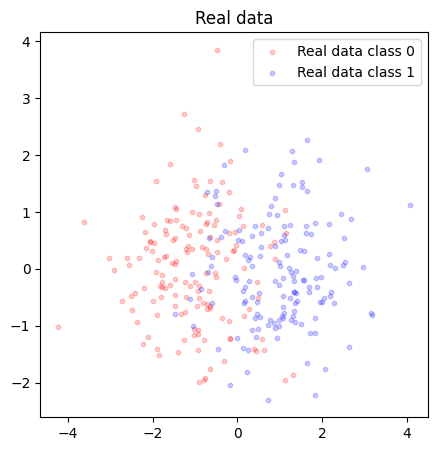

In [15]:
X, y = create_two_blobs_at_distance(
    num_samples=None,
    blob1_num_samples=150,
    blob2_num_samples=150,
    distance=2,
    random_state=40,
)
# ==== scatter the points ====
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c="red", label="Real data class 0", alpha=0.2, s=10)
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c="blue", label="Real data class 1", alpha=0.2, s=10)
ax.set_title("Real data")
ax.legend()
plt.show()

In [16]:
tabebm = TabEBM()
augmented_data = tabebm.generate(
    X,
    y,
    num_samples=50,
    sgld_steps=200,
)

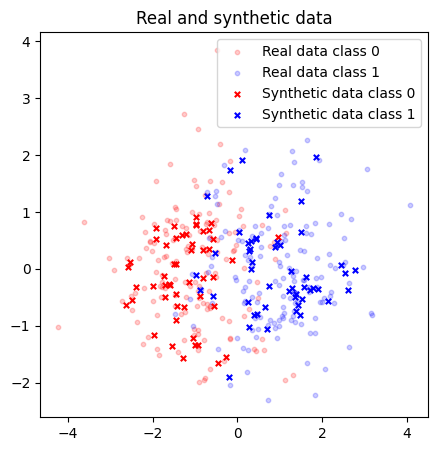

In [17]:
# ==== Scatter the real points ====
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='red', label='Real data class 0', alpha=0.2, s=10)
ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='blue', label='Real data class 1', alpha=0.2, s=10)

# ==== Scatter the generated points ====
ax.scatter(augmented_data['class_0'][:, 0], augmented_data['class_0'][:, 1], c='red', s=15, marker='x', label='Synthetic data class 0')
ax.scatter(augmented_data['class_1'][:, 0], augmented_data['class_1'][:, 1], c='blue', s=15, marker='x', label='Synthetic data class 1')

ax.set_title('Real and synthetic data')
ax.legend()
plt.show()